In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('data/concrete_data.csv')

In [3]:
x=df.drop(columns={'Strength'})
y=df.iloc[:,-1]
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(xTrain,yTrain)
y_pred=lr.predict(xTest)


In [6]:
from sklearn.metrics import r2_score
accuracy=r2_score(yTest,y_pred)
print(accuracy)

0.6275531792314851


In [7]:
from sklearn.model_selection import cross_val_score
lr=LinearRegression()
np.mean(cross_val_score(lr,xTrain,yTrain,scoring='r2'))

np.float64(0.5946055391992531)

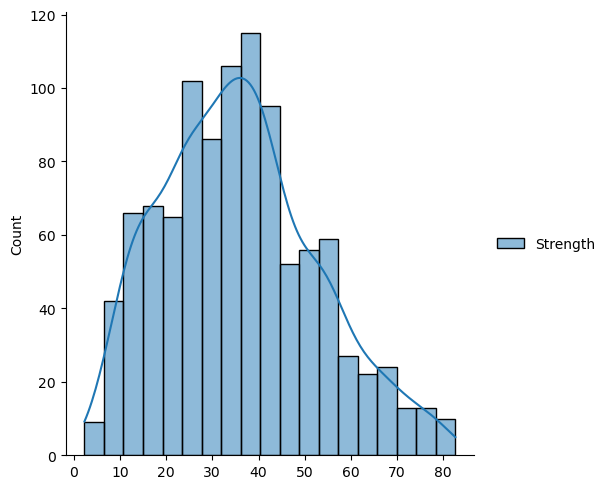

In [8]:
sns.displot(df[['Strength']],kde=True)
# df.columns

C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\1311318754.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrain[col])


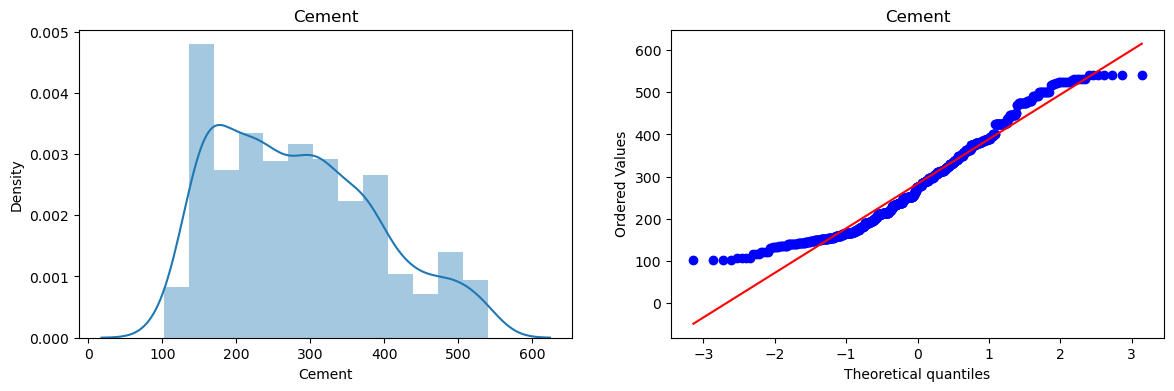

C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\1311318754.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrain[col])


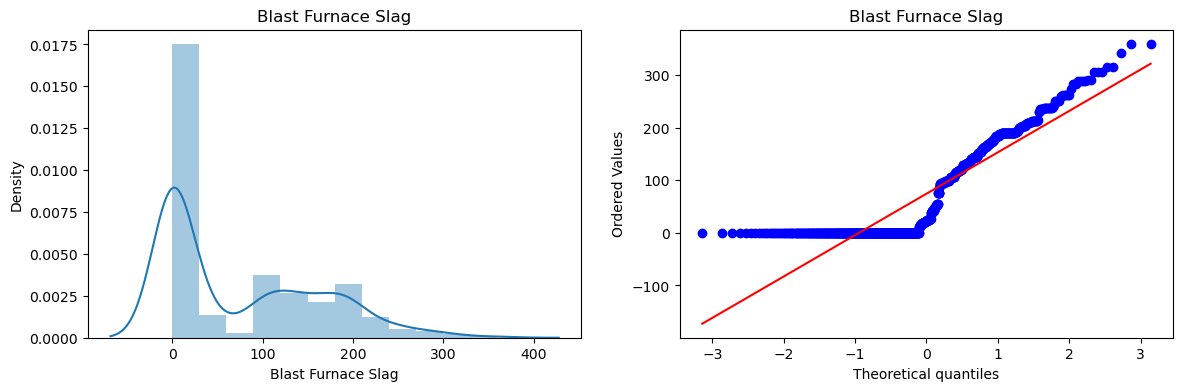

C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\1311318754.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrain[col])


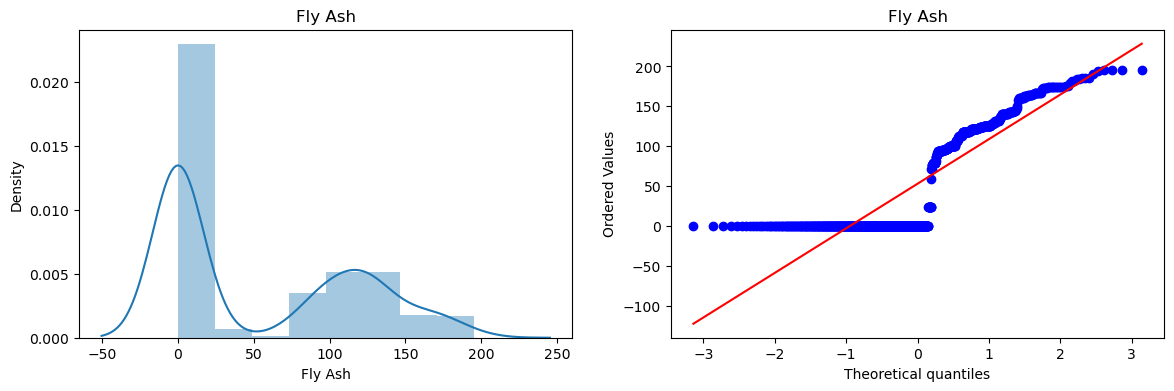

C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\1311318754.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrain[col])


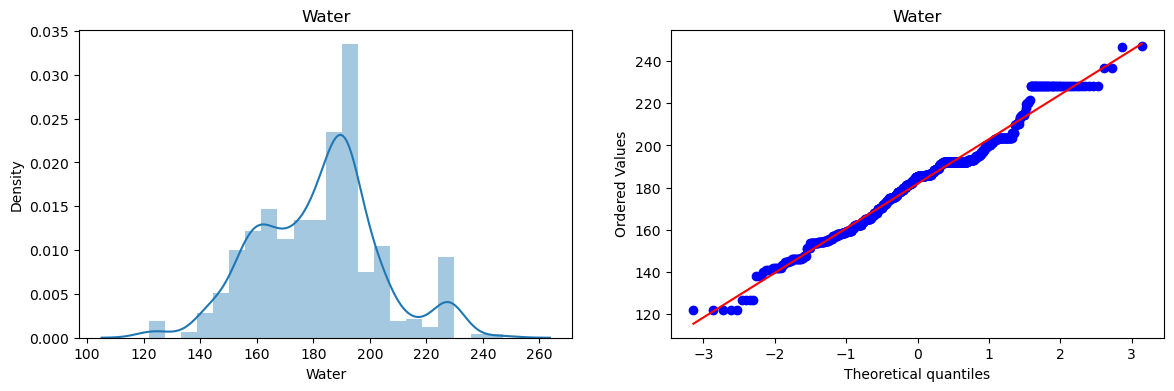

C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\1311318754.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrain[col])


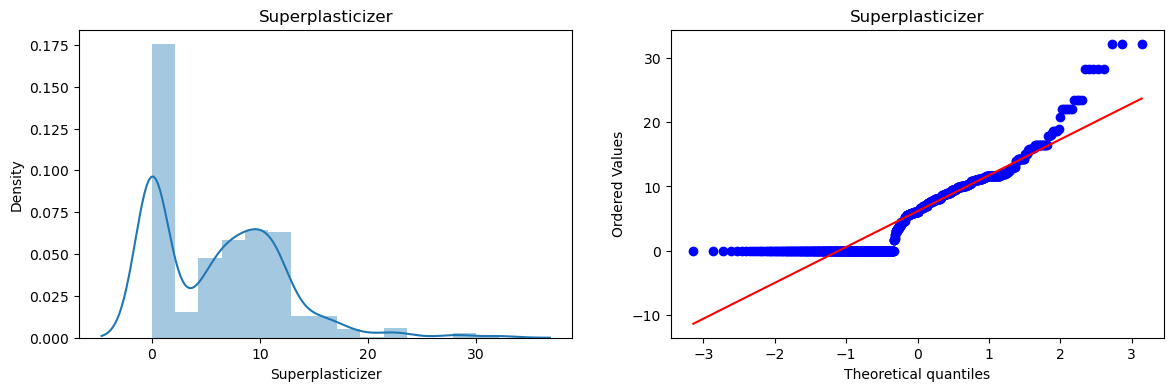

C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\1311318754.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrain[col])


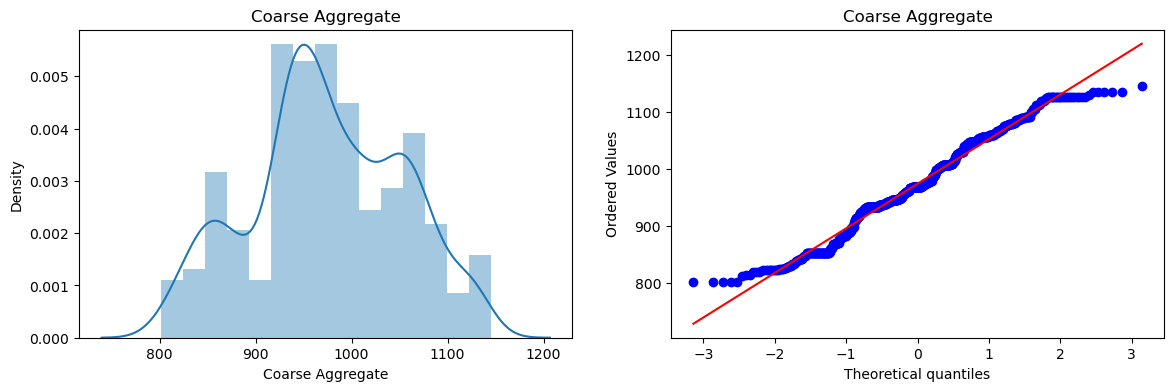

C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\1311318754.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrain[col])


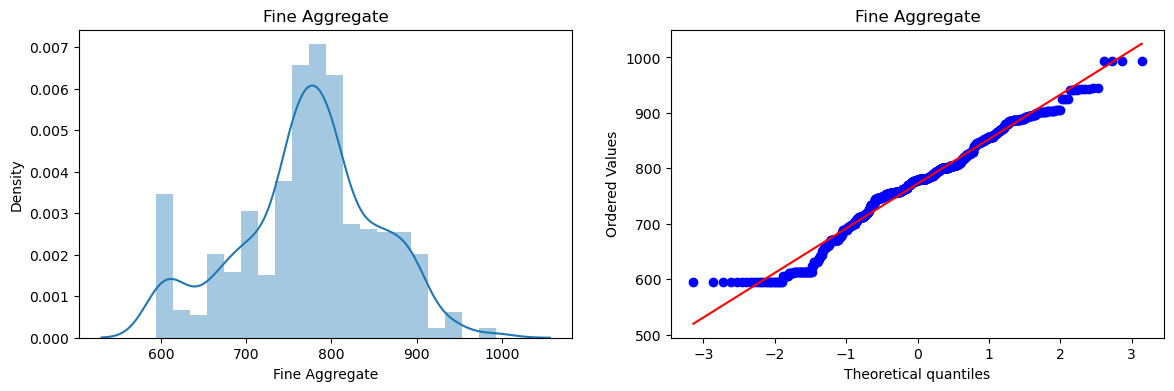

C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\1311318754.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrain[col])


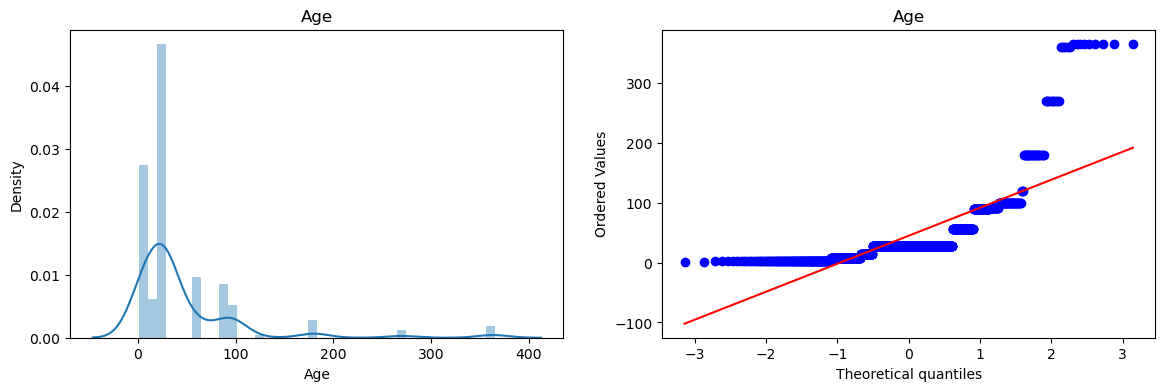

In [9]:
import scipy.stats as stats
for col in xTrain.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(xTrain[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(xTrain[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [10]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='box-cox')
xTrain2=pt.fit_transform(xTrain+0.0001)
xTest2=pt.transform(xTest+0.0001)

In [11]:
lr=LinearRegression()
lr.fit(xTrain2,yTrain)
y_pred2=lr.predict(xTest2)
r2_score(y_pred2,yTest)

0.764292909623607

In [12]:
np.mean(cross_val_score(lr,xTrain2,yTrain,scoring='r2'))

np.float64(0.7926214006840844)

In [13]:
xTrainTransform=pd.DataFrame(xTrain2,columns=xTrain.columns)


C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\279215881.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrainTransform[cols],kde=True)
C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\279215881.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrainTransform[cols],kde=Tr

C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\279215881.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrainTransform[cols],kde=True)
C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_15872\279215881.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xTrainTransform[cols],kde=Tr

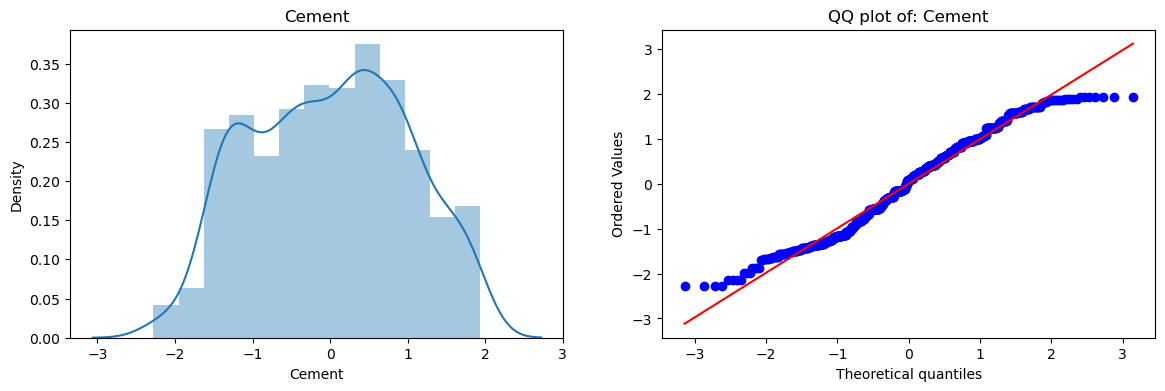

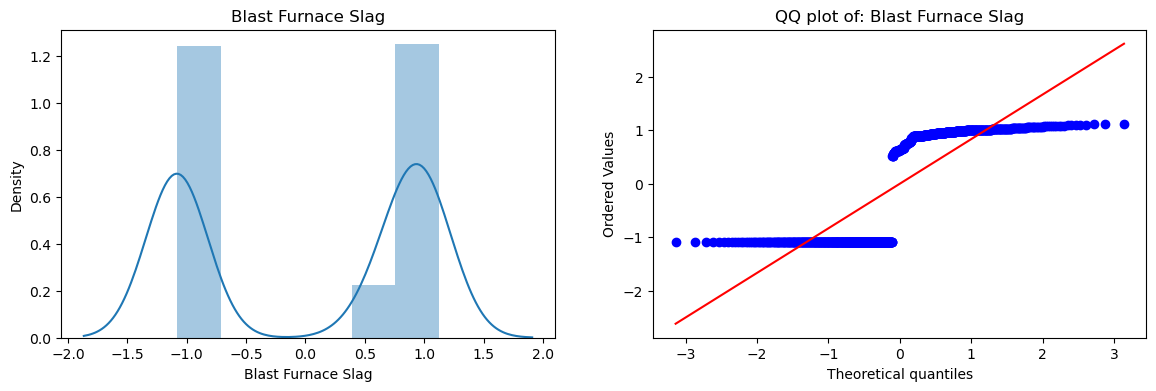

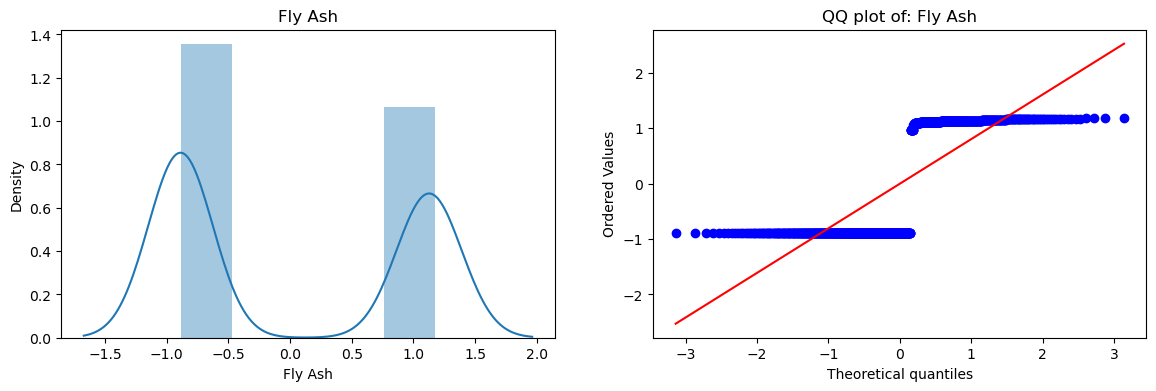

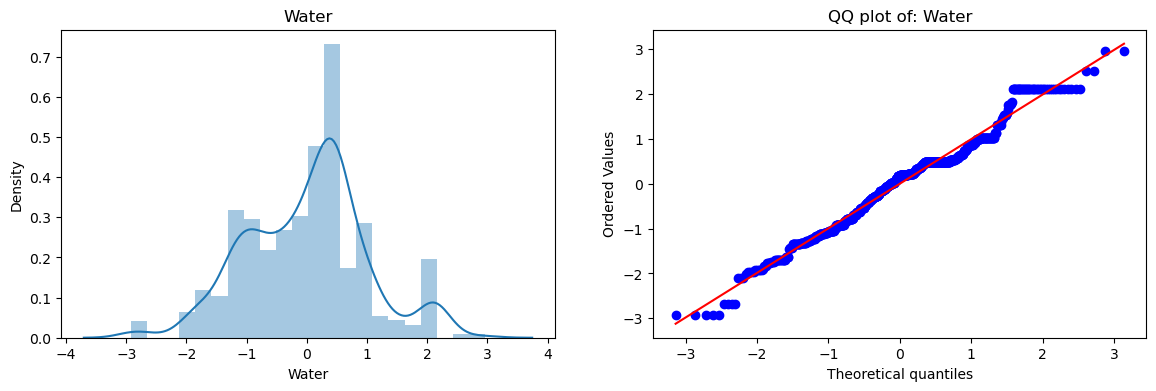

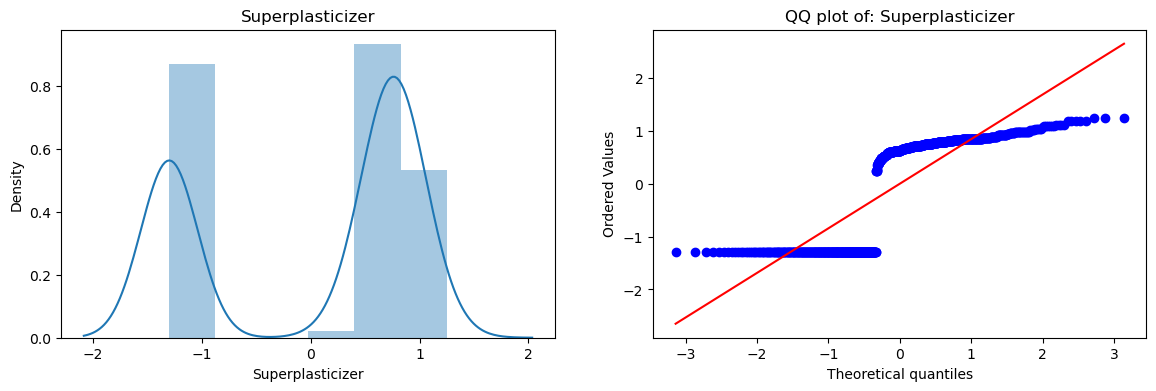

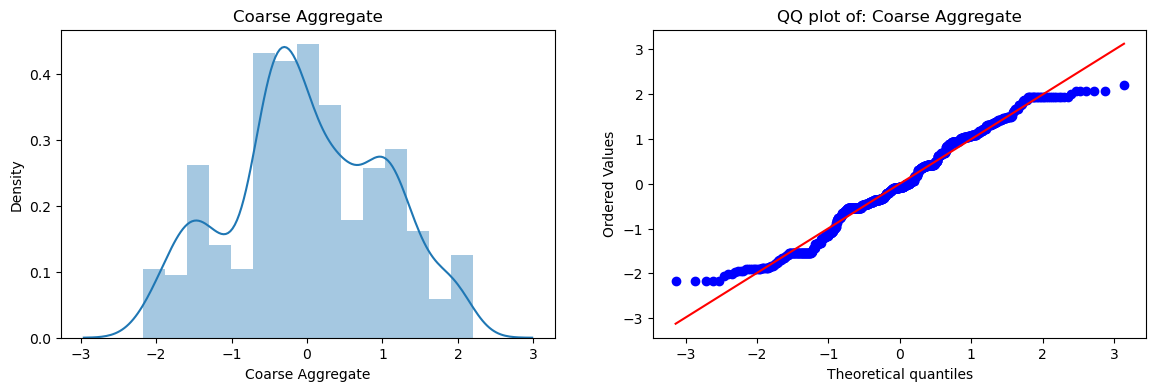

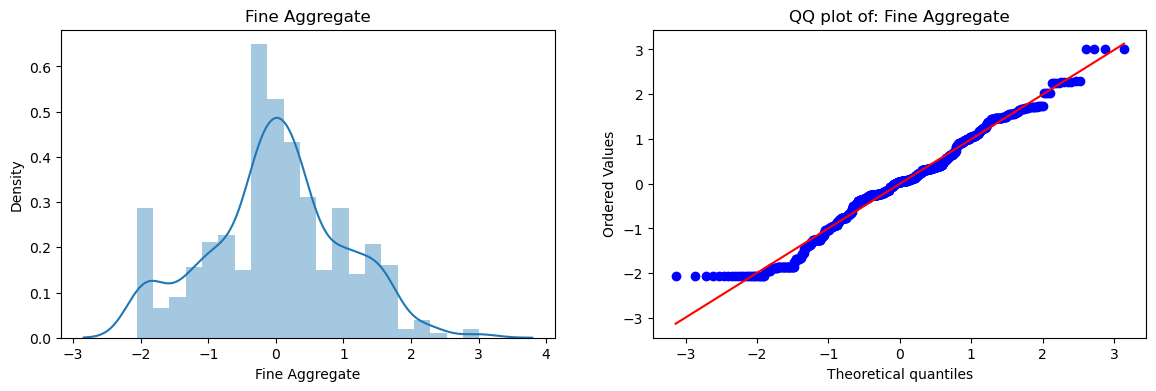

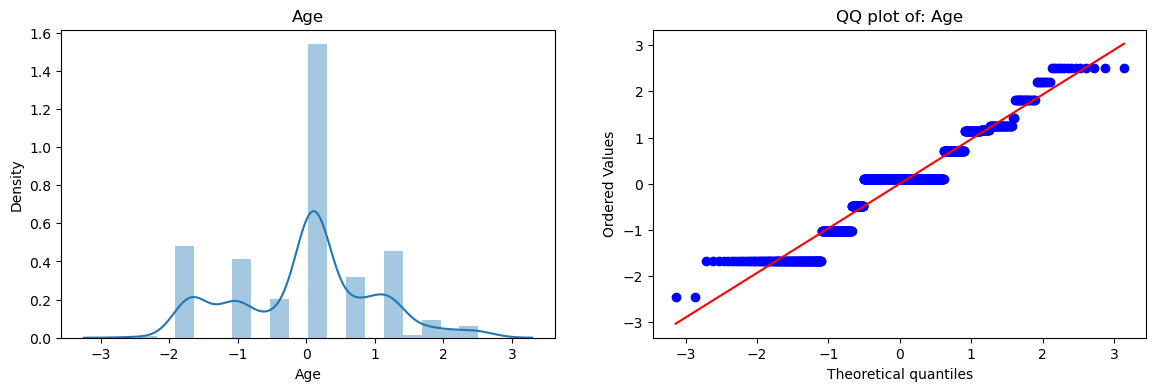

In [14]:
for cols in xTrainTransform.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.distplot(xTrainTransform[cols],kde=True)
  plt.title(cols)

  plt.subplot(122)
  stats.probplot(xTrainTransform[cols], dist="norm", plot=plt)
  plt.title("QQ plot of: "+cols)

In [15]:
yj=PowerTransformer()
xTrainyj=yj.fit_transform(xTrain)
xTestyj=yj.transform(xTest)

lr3=LinearRegression()
lr3.fit(xTrainyj,yTrain)
y_pred=lr3.predict(xTestyj)
print(r2_score(y_pred,yTest))

0.7797686952134393


In [16]:
lr3=LinearRegression()
np.mean(cross_val_score(lr,xTrain2,yTrain,scoring='r2'))

np.float64(0.7926214006840844)